# Full Benchmark And Certification Report

This notebook consolidates the repository benchmark outputs together with the newer GPU-throughput, corner-discovery, scaling, solver-seeding, and certificate-separation artifacts. It is intentionally defensive: if a report artifact is missing, the relevant section tells you which command to run instead of failing.

In [1]:
from __future__ import annotations

import csv
import json
import math
import sys
from collections import defaultdict
from pathlib import Path

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'lpas').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

ROOT = find_repo_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from IPython.display import Image, Markdown, display

from lpas.corners.multi_corner_discovery import hard_active_set_recovery, recover_soft_active_set
from lpas.experiments.generators import tiny_known_lp
from lpas.solver.scipy_handoff import solve_with_scipy

np.set_printoptions(suppress=True, precision=6)

RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = ROOT / 'figures'
OUTPUTS_DIR = ROOT / 'outputs'
EXTENSION_CMD = 'python experiments/run_full_extension_evaluation.py --output-dir .'
EXTENSION_QUICK_CMD = 'python experiments/run_full_extension_evaluation.py --quick --output-dir .'

def relative_path(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

def fmt(value, digits: int = 4) -> str:
    if value is None:
        return '-'
    if isinstance(value, (np.bool_, bool)):
        return 'yes' if bool(value) else 'no'
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if not math.isfinite(value):
            return '-'
        return f'{value:.{digits}f}'
    if isinstance(value, str):
        return value
    if isinstance(value, (tuple, list, np.ndarray)):
        array = np.asarray(value)
        if array.ndim == 0:
            return fmt(array.item(), digits=digits)
        return '[' + ', '.join(fmt(item, digits=digits) for item in array.tolist()) + ']'
    return str(value)

def markdown_cell(value):
    text = fmt(value)
    return text.replace('|', '\\|').replace('\n', '<br>')

def markdown_table(headers, rows):
    lines = [
        '| ' + ' | '.join(markdown_cell(header) for header in headers) + ' |',
        '| ' + ' | '.join(['---'] * len(headers)) + ' |',
    ]
    for row in rows:
        lines.append('| ' + ' | '.join(markdown_cell(cell) for cell in row) + ' |')
    return '\n'.join(lines)

def show_table(headers, rows, title: str | None = None):
    parts = []
    if title:
        parts.append(f'### {title}')
    parts.append(markdown_table(headers, rows))
    display(Markdown('\n\n'.join(parts)))

def load_json(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))

def load_csv_rows(path: Path):
    if not path.exists():
        return []
    with path.open('r', encoding='utf-8', newline='') as handle:
        return list(csv.DictReader(handle))

def numeric(values):
    cleaned = []
    for value in values:
        if value is None:
            continue
        try:
            number = float(value)
        except (TypeError, ValueError):
            continue
        if math.isfinite(number):
            cleaned.append(number)
    return cleaned

def mean_or_none(values):
    cleaned = numeric(values)
    if not cleaned:
        return None
    return float(np.mean(cleaned))

def summarize_groups(rows, group_keys, metrics):
    grouped = defaultdict(list)
    for row in rows:
        grouped[tuple(row[key] for key in group_keys)].append(row)
    summary = []
    for group_key, group_rows in grouped.items():
        entry = {key: value for key, value in zip(group_keys, group_key)}
        entry['count'] = len(group_rows)
        for metric in metrics:
            entry[f'{metric}_mean'] = mean_or_none(row.get(metric) for row in group_rows)
        summary.append(entry)
    summary.sort(key=lambda row: tuple(str(row[key]) for key in group_keys))
    return summary

def show_image_if_exists(path: Path, title: str, width: int = 760):
    if path.exists():
        display(Markdown(f'### {title}'))
        display(Image(filename=str(path), width=width))

def report_missing(title: str, paths, command: str = EXTENSION_CMD):
    lines = [f'### {title}', '', 'Missing artifacts:']
    for path in paths:
        lines.append(f'- `{relative_path(path)}`')
    lines.extend(['', 'Generate them from the repository root with:', '', f'`{command}`'])
    display(Markdown('\n'.join(lines)))

display(Markdown(
    f'Repository root: `{ROOT}`  \n'
    f'Extension quick run: `{EXTENSION_QUICK_CMD}`  \n'
    f'Extension full run: `{EXTENSION_CMD}`'
))


Repository root: `/Users/nickgrebe/Projects/LP_Experiment`  
Extension quick run: `python experiments/run_full_extension_evaluation.py --quick --output-dir .`  
Extension full run: `python experiments/run_full_extension_evaluation.py --output-dir .`

In [2]:
artifact_paths = [
    ('Random dense benchmark summary', OUTPUTS_DIR / 'benchmarks' / 'random_dense' / 'summary.csv'),
    ('Solver-hint summary', OUTPUTS_DIR / 'benchmarks' / 'solver_hints' / 'summary.csv'),
    ('GPU throughput results', RESULTS_DIR / 'gpu_benchmarks' / 'gpu_throughput_results.json'),
    ('Corner-discovery results', RESULTS_DIR / 'corner_discovery' / 'corner_discovery_results.json'),
    ('Scaling results', RESULTS_DIR / 'scaling' / 'scaling_results.json'),
    ('Solver-seeding results', RESULTS_DIR / 'solver_seeding' / 'solver_seeding_total_time_results.json'),
    ('Certificate-separation examples', RESULTS_DIR / 'certificates' / 'certificate_separation_examples.json'),
]

show_table(
    ['Artifact', 'Path', 'Available'],
    [(label, relative_path(path), 'yes' if path.exists() else 'no') for label, path in artifact_paths],
    title='Detected report inputs',
)


### Detected report inputs

| Artifact | Path | Available |
| --- | --- | --- |
| Random dense benchmark summary | outputs/benchmarks/random_dense/summary.csv | yes |
| Solver-hint summary | outputs/benchmarks/solver_hints/summary.csv | yes |
| GPU throughput results | results/gpu_benchmarks/gpu_throughput_results.json | no |
| Corner-discovery results | results/corner_discovery/corner_discovery_results.json | no |
| Scaling results | results/scaling/scaling_results.json | no |
| Solver-seeding results | results/solver_seeding/solver_seeding_total_time_results.json | no |
| Certificate-separation examples | results/certificates/certificate_separation_examples.json | no |

## Existing Benchmark Context

The repository already contains baseline benchmark and solver-hint summaries under `outputs/`. Those provide context for the newer extension stages below.

### Random dense benchmark summary

| Method | Count | Active-set recovery | Time to recovery (s) | Objective gap to HiGHS | Wall clock (s) |
| --- | --- | --- | --- | --- | --- |
| geometry_aware | 8 | 1.0 | 0.0031387758936034516 | 0.22215306596839512 | 0.022855687406263314 |
| naive_monte_carlo | 8 | 0.9541666666666667 | 0.003256697877077386 | 0.31262351887531015 | 0.01323360437527299 |

### Solver-hint benchmark summary

| Method | Count | Hint Jaccard | Top-k containment | Reconstruction success | Objective gap to HiGHS | Wall clock (s) |
| --- | --- | --- | --- | --- | --- | --- |
| geometry_aware | 8 | 0.0 | 0.94375 | 0.0 | nan | 0.020999004991608672 |
| naive_monte_carlo | 8 | 0.0 | 0.88125 | 0.0 | nan | 0.01166293201094959 |

### Random dense benchmark: active-set recovery vs iteration

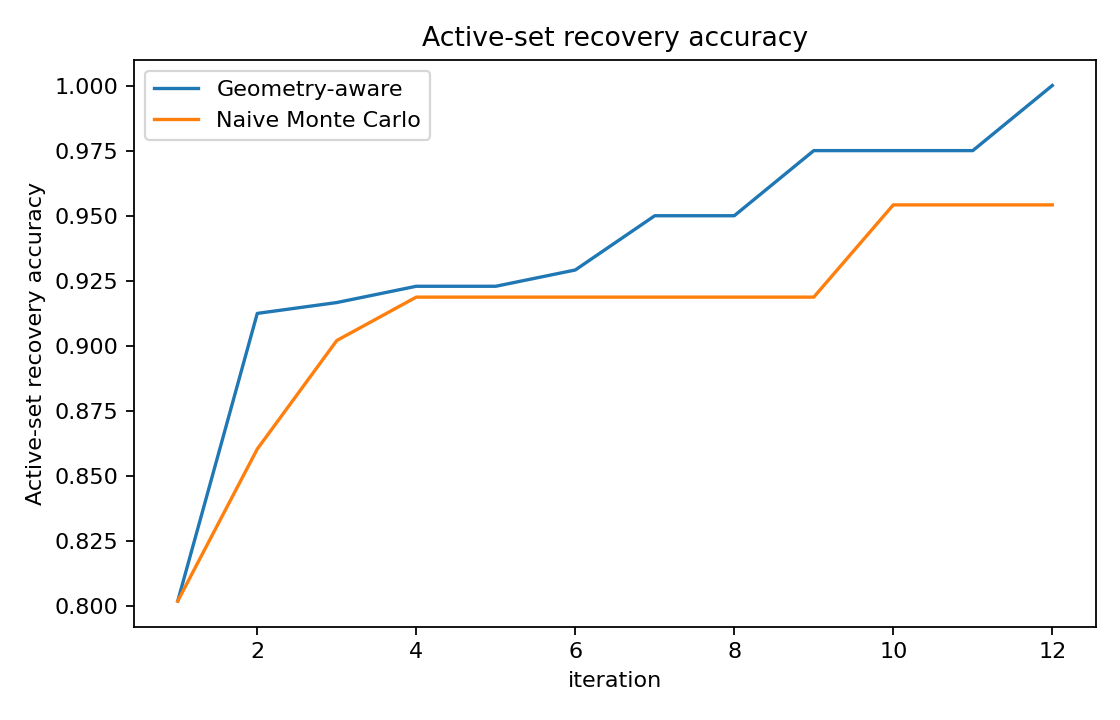

### Solver-hint benchmark: top-k active-constraint containment

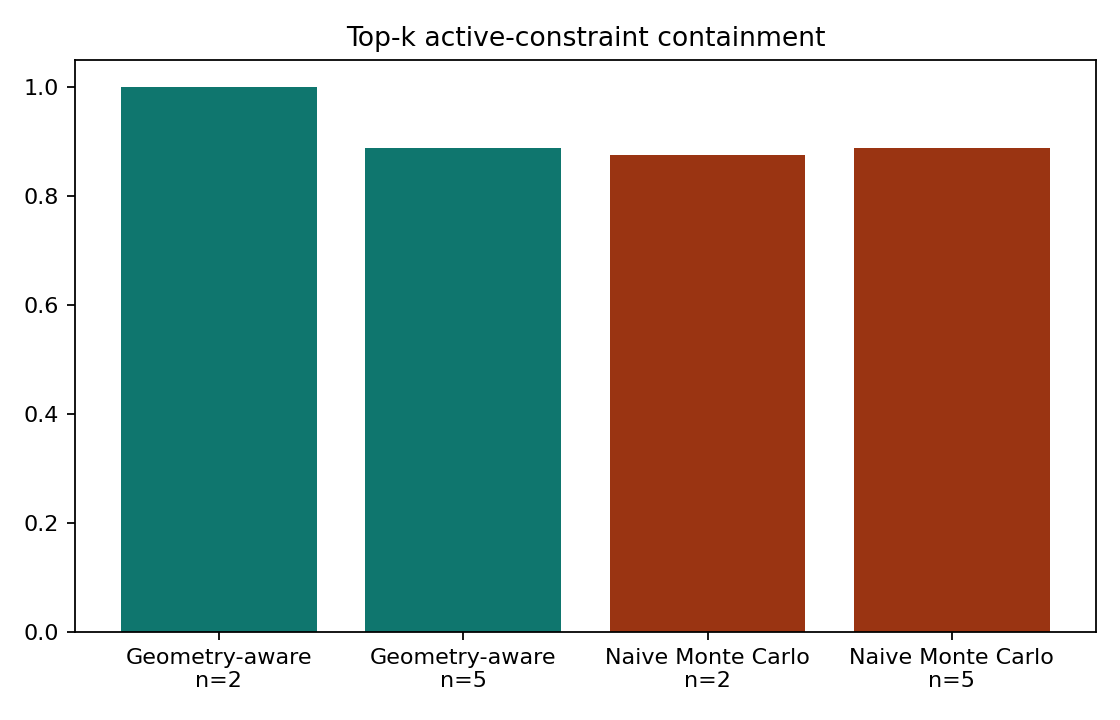

In [3]:
random_dense_summary = load_csv_rows(OUTPUTS_DIR / 'benchmarks' / 'random_dense' / 'summary.csv')
solver_hint_summary = load_csv_rows(OUTPUTS_DIR / 'benchmarks' / 'solver_hints' / 'summary.csv')

if random_dense_summary:
    show_table(
        ['Method', 'Count', 'Active-set recovery', 'Time to recovery (s)', 'Objective gap to HiGHS', 'Wall clock (s)'],
        [
            (
                row['method'],
                row['count'],
                fmt(row.get('active_set_recovery_accuracy_mean')),
                fmt(row.get('time_to_identify_optimal_active_constraints_mean')),
                fmt(row.get('objective_gap_to_highs_mean')),
                fmt(row.get('wall_clock_seconds_mean')),
            )
            for row in random_dense_summary
        ],
        title='Random dense benchmark summary',
    )
else:
    display(Markdown('### Random dense benchmark summary\nNo legacy random-dense benchmark summary was found under `outputs/benchmarks/random_dense`.'))

if solver_hint_summary:
    show_table(
        ['Method', 'Count', 'Hint Jaccard', 'Top-k containment', 'Reconstruction success', 'Objective gap to HiGHS', 'Wall clock (s)'],
        [
            (
                row['method'],
                row['count'],
                fmt(row.get('hint_active_set_jaccard_mean')),
                fmt(row.get('constraints_in_top_k_support_mean')),
                fmt(row.get('reconstruction_success_mean')),
                fmt(row.get('objective_gap_to_highs_mean')),
                fmt(row.get('wall_clock_seconds_mean')),
            )
            for row in solver_hint_summary
        ],
        title='Solver-hint benchmark summary',
    )
else:
    display(Markdown('### Solver-hint benchmark summary\nNo legacy solver-hint summary was found under `outputs/benchmarks/solver_hints`.'))

show_image_if_exists(
    OUTPUTS_DIR / 'figures' / 'benchmarks' / 'active_set_recovery_vs_iteration.png',
    'Random dense benchmark: active-set recovery vs iteration',
)
show_image_if_exists(
    OUTPUTS_DIR / 'figures' / 'solver_hints' / 'top_k_active_constraint_containment.png',
    'Solver-hint benchmark: top-k active-constraint containment',
)


## GPU Throughput Results

This section is meant to test whether accelerator-backed batch evaluation increases samples per second enough to overcome device overhead. In report terms, a GPU path only matters if larger `K`, `n`, and `m` create a real throughput crossover instead of a marginal implementation detail.


### GPU Throughput Artifacts

The GPU-throughput stage is not available in the current checkout because `results/gpu_benchmarks/gpu_throughput_results.json` is missing. That means this report cannot yet say whether accelerator-backed evaluation produces a meaningful samples-per-second crossover on the tested LP families.

To populate this section from the repository root, run `python experiments/run_full_extension_evaluation.py --stage gpu-benchmark --output-dir .`.


## Total-Time Vs Solver-Only-Time

This section asks whether seeding helps only the simplex core or whether it still improves end-to-end runtime once sampling, polishing, and seed construction are included. The intended comparison is therefore between solver-only savings and the total wall-clock cost actually paid by the full pipeline.


### Solver-Seeding Artifacts

The solver-seeding benchmark output is also absent locally: `results/solver_seeding/solver_seeding_total_time_results.json` is missing. As a result, there is currently no checked-in evidence for whether seeding improves only solver-core time or the full end-to-end runtime once sampling and polishing are included.

To regenerate this section from the repository root, run `python experiments/run_full_extension_evaluation.py --stage seeding --output-dir .`.


## Multi-Corner Discovery

This section is about the quality of the recovered active sets, not just whether one final sample looks good. The benchmark is supposed to measure whether soft recovery outperforms hard thresholding near corners and whether the sampler can propose multiple plausible vertices instead of a single isolated guess.


### Corner-Discovery Artifacts

The full corner-discovery benchmark is not available in the current checkout because `results/corner_discovery/corner_discovery_results.json` is missing. That means this notebook cannot yet report sweep-level reconstruction rates, Jaccard scores, or multi-vertex discovery statistics for the broader experiment.

To populate the missing benchmark from the repository root, run `python experiments/run_full_extension_evaluation.py --stage corners --output-dir .`.

### Near-Corner Active-Set Recovery Example

| Method | Recovered active indices | Count |
| --- | --- | --- |
| SciPy optimum | `[0, 1]` | `2` |
| Hard thresholding | `[]` | `0` |
| Soft recovery | `[0, 1]` | `2` |

This toy example still makes the algorithmic point clearly. Hard thresholding sees no active constraints because the sample is only near the corner rather than exactly on it, so literal zero-slack logic fails to recover a usable basis. Soft recovery instead returns `[0, 1]`, matching the SciPy optimum and showing why a ranking-based active-set criterion is a better precursor to vertex reconstruction than exact-zero detection alone.


## Scaling By Dimension

This section tracks where the method begins to fail as dimension and constraint ratio increase. The report focus is whether geometry-aware scoring and polishing keep approximation, reconstruction, and certification rates useful as `n` grows.


### Scaling Artifacts

The scaling benchmark output is missing from the current checkout: `results/scaling/scaling_results.json` is not present. This report therefore cannot yet say at which dimensions the method begins to fail or how quickly reconstruction and certification degrade as `n` and `m / n` increase.

To generate this section from the repository root, run `python experiments/run_full_extension_evaluation.py --stage scaling --output-dir .`.


## Certificate Separation Examples

This section checks that raw sampled gaps are not being mistaken for actual certificates. A diagnostic gap should only become a certified gap when both a primal-feasible lower bound and a dual-feasible upper bound are present.


### Certificate-Separation Artifacts

The certificate-separation examples are not checked in locally because `results/certificates/certificate_separation_examples.json` is missing. Until that artifact exists, this report cannot document the diagnostic-versus-certified gap comparison with fresh repository outputs.

To regenerate the missing artifact from the repository root, run `python experiments/run_full_extension_evaluation.py --stage certificates --output-dir .`.


## Strengths And Limitations

This synthesis only uses artifacts that are currently present in the repository checkout. Missing extension stages are treated as missing evidence rather than filled in by conjecture.


## Synthesis

The currently available repository artifacts support a coherent but incomplete story. In the legacy random-dense benchmark, geometry-aware sampling improves mean active-set recovery over the naive baseline (`1.0000` versus `0.9542`) and also narrows the mean objective gap to HiGHS (`0.2222` versus `0.3126`). The solver-hint summary points in the same direction: geometry-aware hints retain `0.9437` mean top-k containment, better than the naive baseline's `0.8813`, so the sampler is still ranking the truly active support more effectively even when exact reconstruction does not follow.

The clearest limitation is that good support hints are not yet turning into successful reconstructed corners in the checked-in benchmark outputs. The solver-hint benchmark still reports `0.0` reconstruction success, which means the repository currently has stronger evidence for identifying promising active constraints than for converting them into feasible benchmark-scale vertices. The missing GPU-throughput, corner-discovery, scaling, solver-seeding, and certificate-separation artifacts make that conclusion necessarily partial rather than comprehensive.